# **MultiModal RAG App for Video Processing With LlamaIndex and LanceDB**

### 1. llamaindex framework
### 2. Lancedb Vector DataBase
### 3. LLM MultiModAl GPT-4V or Google-gemini-pro-vision


# **Steps Need to follow:**
#### 1. Download video from YouTube, process and store it.

#### 2. Build Multi-Modal index and vector store for both texts and images.

#### 3. Retrieve relevant images and context, use both to augment the prompt.

#### 4. Using GPT4V for reasoning the correlations between the input query and augmented data and generating final response.

In [ ]:
%pip install llama-index-vector-stores-lancedb
%pip install llama-index-multi-modal-llms-openai
%pip install llama-index-embeddings-clip
%pip install git+https://github.com/openai/CLIP.git
!pip install llama-index-readers-file

In [ ]:
%pip install llama_index
%pip install -U openai-whisper

In [ ]:
%pip install lancedb
%pip install moviepy
%pip install pytube
%pip install pydub
%pip install SpeechRecognition
%pip install ffmpeg-python
%pip install soundfile
%pip install torch torchvision
%pip install matplotlib scikit-image
%pip install ftfy regex tqdm

ffmpeg-library enables you to use FFmpeg in Python to manipulate various media files for different purposes like building comprehensive multimedia applications, preprocessing media files.

MoviePy is a Python library for video editing, enabling cutting, concatenations, title insertions, video compositing, and effects like animations or color grading.

Pytube is a Python library used for downloading videos from YouTube. It supports downloading in various formats, resolutions, and also direct audio extraction.


Pydub is a Python library for audio manipulation, enabling easy loading,
editing, and exporting of audio files in various formats with minimal code.

The SpeechRecognition library in Python allows you to convert spoken language into text using various engines and APIs, such as Google Speech Recognition, IBM Speech to Text, etc.


SoundFile is a Python library for reading from and writing to audio files, supporting many formats through the libsndfile library, ideal for high-quality audio processing.

FTFY (Fix Text For You) is a Python library that fixes broken Unicode text and mojibake (garbled text due to encoding issues), making text legible again.

OpenAI Whisper is a robust, multilingual speech recognition model developed by OpenAI. It converts speech into text and supports various languages with high accuracy.

pprint is a Python module that provides a capability to "pretty-print" complex data structures in a well-formatted and more readable way than the basic print function.

In [1]:
import sys
print(sys.executable)

f:\Multimodal-RAG-Systems\.venv\Scripts\python.exe


In [2]:
from pathlib import Path
import speech_recognition as sr
from pytube import YouTube
from pprint import pprint
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
import os
print(os.getcwd())

f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB


In [4]:
video_url="https://youtu.be/3dhcmeOTZ_Q"

## Define the Video Storage Path

Set up the project directory and create a `video_data` folder to store the downloaded YouTube video. If the folder does not already exist, it will be created automatically. Also define the path for the input video file.

In [5]:
from pathlib import Path

# Current project directory
project_dir = Path.cwd()

# Folder where the downloaded video will be stored
output_video_path = project_dir / "video_data"

# Create the folder if it doesn't exist
output_video_path.mkdir(parents=True, exist_ok=True)

# Input video file
input_video_path = output_video_path / "input_vid.mp4"

print(output_video_path)
print(input_video_path)

f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\video_data
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\video_data\input_vid.mp4


## Define the Output Storage Paths

Set up the `mixed_data` folder to store all generated outputs, including extracted video frames, the audio file, and the transcribed text. If the folder does not already exist, it will be created automatically.

In [6]:
from pathlib import Path

# Current project directory
project_dir = Path.cwd()

# Folder where extracted images, audio, and text will be saved
output_folder = project_dir / "mixed_data"

# Create the folder if it doesn't exist
output_folder.mkdir(parents=True, exist_ok=True)

# Output files
output_audio_path = output_folder / "output_audio.wav"
output_text_path = output_folder / "output_text.txt"

print(output_folder)
print(output_audio_path)
print(output_text_path)

f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\output_audio.wav
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\output_text.txt


### Download Video

In [7]:
from yt_dlp import YoutubeDL

def download_video(url, output_path):
    ydl_opts = {
        "format": "best[ext=mp4]/best",
        "outtmpl": str(output_path / "input_vid.%(ext)s"),
        "quiet": True,
        "noplaylist": True,
    }

    with YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)

    metadata = {
        "Author": info.get("uploader"),
        "Title": info.get("title"),
        "Views": info.get("view_count"),
    }

    return metadata

### Video to Images

In [8]:
from moviepy.editor import VideoFileClip

def video_to_images(video_path, output_folder):
    clip = VideoFileClip(str(video_path))

    clip.write_images_sequence(
        str(output_folder / "frame%04d.png"),
        fps=0.2
    )

### Video to Audio

In [9]:
from moviepy.editor import VideoFileClip

def video_to_audio(video_path, output_audio_path):
    clip = VideoFileClip(str(video_path))
    audio = clip.audio
    audio.write_audiofile(str(output_audio_path))

### Audio to Text


In [10]:
from faster_whisper import WhisperModel

In [11]:
# Load the Whisper model (downloads on first run)
model = WhisperModel("base", device="cpu", compute_type="int8")

def audio_to_text(audio_path):
    segments, info = model.transcribe(str(audio_path))

    # Combine all transcript segments into one string
    text = " ".join(segment.text for segment in segments)

    return text

### Save Text

In [12]:
def save_text(text_data, output_text_path):
    output_text_path.write_text(text_data, encoding="utf-8")
    print("Text data saved successfully!")

## Step 1: Download the YouTube Video
Download the YouTube video and extract its metadata (author, title, and views).

In [13]:
video_url

'https://youtu.be/3dhcmeOTZ_Q'

In [14]:
output_video_path

WindowsPath('f:/Multimodal-RAG-Systems/MultiModal_RAG_with_llamaIndex_and_LanceDB/video_data')

In [15]:
metadata = download_video(video_url, output_video_path)

print(metadata)

{'Author': '3-Minute Data Science', 'Title': 'Linear Regression in 3 Minutes', 'Views': 341979}


## Step 2: Extract Images from the Video
Extract frames from the downloaded video and save them to the `mixed_data` folder.

In [16]:
video_to_images(input_video_path, output_folder)

print("Frames extracted successfully!")

Moviepy - Writing frames f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame%04d.png.


Moviepy - Done writing frames f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame%04d.png.
Frames extracted successfully!


## Step 3: Extract Audio from the Video
Extract the audio track from the downloaded video and save it as a WAV file.

In [17]:
input_video_path

WindowsPath('f:/Multimodal-RAG-Systems/MultiModal_RAG_with_llamaIndex_and_LanceDB/video_data/input_vid.mp4')

In [18]:
output_audio_path

WindowsPath('f:/Multimodal-RAG-Systems/MultiModal_RAG_with_llamaIndex_and_LanceDB/mixed_data/output_audio.wav')

In [19]:
video_to_audio(input_video_path, output_audio_path)

print("Audio extracted successfully!")

MoviePy - Writing audio in f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\output_audio.wav


MoviePy - Done.
Audio extracted successfully!


## Step 4: Convert Audio to Text
Transcribe the extracted audio into text using Google's Speech Recognition API.

In [20]:
text_data = audio_to_text(output_audio_path)

print(text_data)

Exception ignored in: <function FFMPEG_VideoReader.__del__ at 0x00000207E51F0680>
Traceback (most recent call last):
  File "f:\Multimodal-RAG-Systems\.venv\Lib\site-packages\moviepy\video\io\ffmpeg_reader.py", line 199, in __del__
    self.close()
  File "f:\Multimodal-RAG-Systems\.venv\Lib\site-packages\moviepy\video\io\ffmpeg_reader.py", line 190, in close
    self.proc.terminate()
  File "C:\Python311\Lib\subprocess.py", line 1673, in terminate
    _winapi.TerminateProcess(self._handle, 1)
OSError: [WinError 6] The handle is invalid


 Lenny regression is a statistical technique for modeling the relationship between an output  variable and one or more input variables.  In layman's terms, think of it as fitting a line through some data points as shown here,  so you can make predictions on unknown data, assuming there is a linear relationship between  the variables.  You might be familiar with the linear function y equals mx plus b, where y is the output  variable, also called the dependent variable.  You may also see expressed as f of x, the function of the input variable, x on the other hand  would serve as the input variable, also called the independent variable.  It's likely you'll see the coefficients m and b expressed as beta 1 and beta 0 respectively.  So what do the m and b coefficients do?  The m or beta 1 coefficient controls the slope of the line, the b or the beta 0 controls  the intercept of the line, in machine learning, we also know it as the bias.  These two coefficients are what we are solving for in 

## Step 5: Save the Transcribed Text
Save the transcribed text into a text file for later use.

In [21]:
save_text(text_data, output_text_path)

Text data saved successfully!


## Step 6: Verify the Generated Files
Display all files generated during preprocessing.

In [22]:
for file in output_folder.iterdir():
    print(file)

f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0000.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0001.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0002.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0003.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0004.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0005.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0006.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0007.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0008.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0009.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and

## Remove the Temporary Audio File

Delete the extracted audio file after it has been successfully converted into text. This helps free up disk space and keeps the project directory clean by removing intermediate files that are no longer needed.

In [23]:

os.remove(output_audio_path)
print("Audio file removed")

Audio file removed


In [22]:
#process the video
#image
#text

## Load the Multimodal Documents

Load all supported files from the `mixed_data` directory into LlamaIndex using the `SimpleDirectoryReader`.

In [25]:
from llama_index.core import SimpleDirectoryReader
documents = SimpleDirectoryReader(output_folder).load_data()

In [26]:
len(documents)

48

## Import Required LlamaIndex Modules

Import the necessary LlamaIndex modules for loading multimodal data, creating vector stores, managing storage, and building a multimodal vector index.

In [29]:
from llama_index.core.indices import MultiModalVectorStoreIndex
from llama_index.core import SimpleDirectoryReader
from llama_index.core import StorageContext

from llama_index.vector_stores.lancedb import LanceDBVectorStore

## Create LanceDB Vector Stores

Create separate LanceDB vector stores for text and image embeddings. This allows text and images to be indexed and retrieved independently.

In [30]:
text_store=LanceDBVectorStore(uri="lancedb",table_name="text_collection")
image_store=LanceDBVectorStore(uri="lancedb",table_name="image_collection")

2026-07-13 14:55:17,932 - WARNING - Table text_collection doesn't exist yet. Please add some data to create it.
2026-07-13 14:55:18,140 - WARNING - Table image_collection doesn't exist yet. Please add some data to create it.


## Create a Storage Context

Initialize a storage context that combines the text and image vector stores. This storage context will be used while creating the multimodal index.

In [31]:
storage_context=StorageContext.from_defaults(vector_store=text_store,image_store=image_store)

## Build the MultiModalVectorStoreIndex

Generate text and image embeddings and store them in the corresponding LanceDB collections.

### 1. Text Embedding Model (Free)

In [32]:
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.core import Settings

Settings.embed_model = HuggingFaceEmbedding(
    model_name="BAAI/bge-small-en-v1.5"
)

2026-07-13 14:56:17,131 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-small-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-07-13 14:56:17,134 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-07-13 14:56:17,157 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-small-en-v1.5/5c38ec7c405ec4b44b94cc5a9bb96e735b38267a/modules.json "HTTP/1.1 200 OK"
2026-07-13 14:56:17,811 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-small-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-07-13 14:56:17,891 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-small-en-v1.5/5c38ec7c405ec4b44b94cc5a9bb96e735b38267a/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-07-13 14:56:17,945 - INFO - Loading SentenceTransformer model from BAAI/b

### 2. Image Embedding Model

In [33]:
from llama_index.embeddings.clip import ClipEmbedding

Settings.image_embed_model = ClipEmbedding(
    model_name="ViT-B/32"
)

## Create a Multimodal Vector Index

Build a **Multimodal Vector Index** from the loaded documents. During this process, LlamaIndex generates embeddings for both **text** and **images**, stores them in the configured **LanceDB vector stores**, and creates a unified index for semantic retrieval. This index is later used to search and retrieve the most relevant text and images based on a user query.

In [34]:
index = MultiModalVectorStoreIndex.from_documents(
    documents,
    storage_context=storage_context
)

2026-07-13 14:59:47,388 - INFO - Create new table text_collection adding data.
2026-07-13 15:00:05,695 - INFO - Create new table image_collection adding data.


```text
mixed_data/
│
├── output_text.txt
│   │
│   ▼
│   HuggingFaceEmbedding
│   (BAAI/bge-small-en-v1.5)
│
├── frame0001.png
├── frame0002.png
│   │
│   ▼
│   ClipEmbedding
│   (ViT-B/32)
│
▼
MultiModalVectorStoreIndex
│
▼
LanceDB
├── text_collection
└── image_collection
```

## Create the Multimodal Retriever

Create a retriever that searches both text and image embeddings. It returns the most relevant text result and the top matching images for a given query.

In [35]:
retriever = index.as_retriever(
    similarity_top_k=3,
    image_similarity_top_k=5
)

## Retrieve Relevant Results

Ask a natural language question and retrieve the most relevant text chunks and image frames.

In [36]:
query = "Explain the concept discussed in the video."

retrieved_nodes = retriever.retrieve(query)

2026-07-13 15:00:27,240 - INFO - query_type :, vector
2026-07-13 15:00:37,652 - INFO - query_type :, vector


In [37]:
retrieved_nodes

[NodeWithScore(node=TextNode(id_='2e1120ea-8d92-4933-be64-244ad3259d8b', embedding=[0.010904080234467983, 0.016270197927951813, -0.010588869452476501, -0.0221038069576025, 0.0274495929479599, -0.018974538892507553, 0.026219133287668228, 0.0864204615354538, 0.031122328713536263, 0.0017691194079816341, 0.07193028181791306, -0.05167711153626442, 0.02976580522954464, -0.015542922541499138, 0.029692664742469788, -0.009537830948829651, -0.020988821983337402, 0.007393322419375181, -0.005316083785146475, -0.003316569607704878, 0.07330174744129181, 0.0003280809032730758, -0.016933659091591835, -0.03642464801669121, 0.07535713165998459, -0.006186359561979771, 0.017474209889769554, -0.0052102175541222095, 0.015045355074107647, -0.22848466038703918, 0.0604412667453289, 0.0658501535654068, 0.005752130411565304, -0.02557329274713993, -0.0025980339851230383, 0.03532155230641365, 0.023985225707292557, -0.017750177532434464, -0.021555645391345024, 0.016557345166802406, -0.0034677640069276094, -0.036609

## Display the Retrieved Results

Inspect the retrieved text chunks, image nodes, metadata, and similarity scores.

In [38]:
for node in retrieved_nodes:
    print(node)
    print("-" * 80)

Node ID: 2e1120ea-8d92-4933-be64-244ad3259d8b
Text: Lenny regression is a statistical technique for modeling the
relationship between an output  variable and one or more input
variables.  In layman's terms, think of it as fitting a line through
some data points as shown here,  so you can make predictions on
unknown data, assuming there is a linear relationship between  the
variables.  You might b...
Score:  0.430

--------------------------------------------------------------------------------
Node ID: 8fd260a5-1e3a-4723-bf31-489f9ef52138
Text:
Score:  0.000

--------------------------------------------------------------------------------
Node ID: 5bb27b87-561c-4865-97e9-3e65b0a10bdf
Text:
Score:  0.000

--------------------------------------------------------------------------------
Node ID: f374d7a0-98c8-42af-a83d-e43d2f5589c4
Text:
Score:  0.000

--------------------------------------------------------------------------------
Node ID: 54471ec8-6493-40de-a5de-a989e4d385e7
Text:
Score

### Querying the Retriever for Visual Content

In [39]:
# Ask about the visual content
query = "What objects, charts, or diagrams are shown in the video?"

retrieved_nodes = retriever.retrieve(query)

2026-07-13 15:01:59,965 - INFO - query_type :, vector
2026-07-13 15:02:00,207 - INFO - query_type :, vector


In [40]:
for node in retrieved_nodes:
    print(node)
    print("-" * 80)

Node ID: 2e1120ea-8d92-4933-be64-244ad3259d8b
Text: Lenny regression is a statistical technique for modeling the
relationship between an output  variable and one or more input
variables.  In layman's terms, think of it as fitting a line through
some data points as shown here,  so you can make predictions on
unknown data, assuming there is a linear relationship between  the
variables.  You might b...
Score:  0.419

--------------------------------------------------------------------------------
Node ID: 8fd260a5-1e3a-4723-bf31-489f9ef52138
Text:
Score:  0.000

--------------------------------------------------------------------------------
Node ID: efd03f9c-9ff1-4e51-aa43-5966e2af91a7
Text:
Score:  0.000

--------------------------------------------------------------------------------
Node ID: f374d7a0-98c8-42af-a83d-e43d2f5589c4
Text:
Score:  0.000

--------------------------------------------------------------------------------
Node ID: 5bb27b87-561c-4865-97e9-3e65b0a10bdf
Text:
Score

In [41]:
for node in retrieved_nodes:
    print(node.metadata.get("file_path"))

f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\output_text.txt
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0003.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0038.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0040.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0042.png
f:\Multimodal-RAG-Systems\MultiModal_RAG_with_llamaIndex_and_LanceDB\mixed_data\frame0041.png


In [42]:
# Display the similarity score for each retrieved node
for node in retrieved_nodes:
    print(f"Similarity Score: {node.score:.4f}")

Similarity Score: 0.4193
Similarity Score: 0.0000
Similarity Score: 0.0000
Similarity Score: 0.0000
Similarity Score: 0.0000
Similarity Score: 0.0000


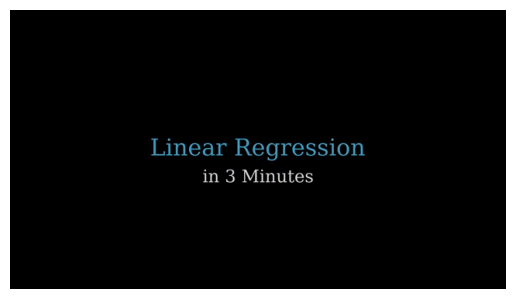

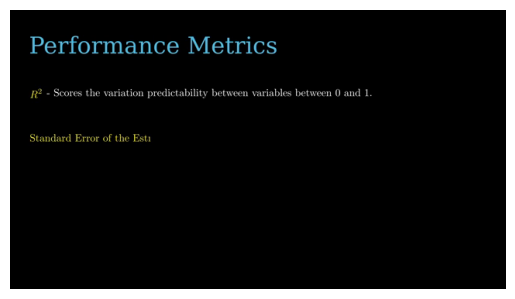

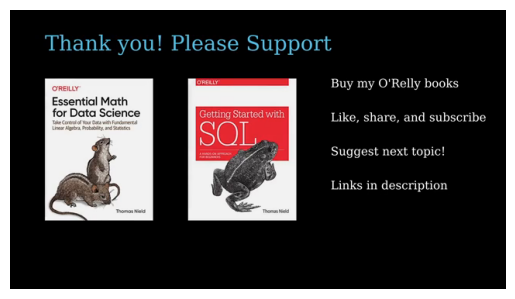

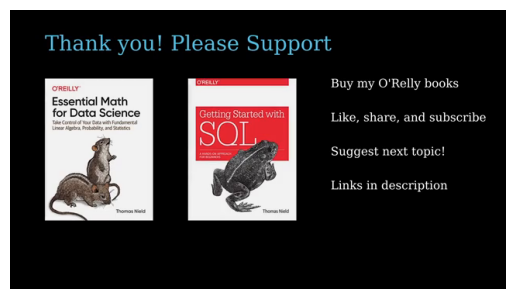

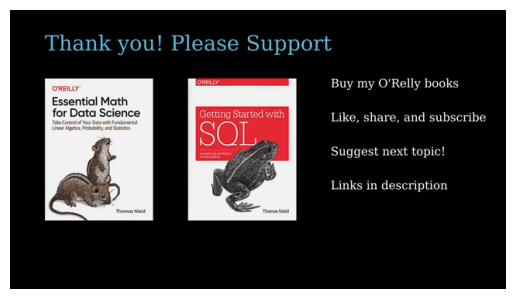

In [43]:
from PIL import Image
import matplotlib.pyplot as plt

# Display the retrieved image frames
for node in retrieved_nodes:
    file_path = node.metadata.get("file_path")

    if file_path and file_path.endswith((".png", ".jpg", ".jpeg")):
        img = Image.open(file_path)

        plt.imshow(img)
        plt.axis("off")
        plt.show()

## Create a Retrieval Helper Function

Define a helper function to retrieve the most relevant text chunks and image frames from the multimodal index. The function separates text and image results for further processing.

In [44]:
from llama_index.core.response.notebook_utils import display_source_node
from llama_index.core.schema import ImageNode

In [45]:
def retrieve(retriever, query):
    retrieval_results = retriever.retrieve(query)

    retrieved_images = []
    retrieved_text = []

    for result in retrieval_results:
        if isinstance(result.node, ImageNode):
            retrieved_images.append(result.node.metadata["file_path"])
        else:
            display_source_node(result, source_length=200)
            retrieved_text.append(result.text)

    return retrieved_images, retrieved_text

## Retrieve Relevant Text and Images

Ask a natural language question and retrieve the most relevant text chunks and image frames from the multimodal index.

In [46]:
query = "Can you explain linear regression and the equation of multiple linear regression?"

images, text = retrieve(retriever, query)

2026-07-13 15:05:50,495 - INFO - query_type :, vector
2026-07-13 15:05:50,715 - INFO - query_type :, vector


**Node ID:** 2e1120ea-8d92-4933-be64-244ad3259d8b<br>**Similarity:** 0.639060914516449<br>**Text:** Lenny regression is a statistical technique for modeling the relationship between an output  variable and one or more input variables.  In layman's terms, think of it as fitting a line through some...<br>

## Visualize the Retrieved Images

Display the retrieved image frames to verify that the retriever has selected visually relevant content.

In [47]:
import os
from PIL import Image
import matplotlib.pyplot as plt

def plot_images(image_paths, max_images=5):
    plt.figure(figsize=(16, 9))

    images_shown = 0

    for image_path in image_paths:
        if os.path.isfile(image_path):

            image = Image.open(image_path)

            plt.subplot(2, 3, images_shown + 1)
            plt.imshow(image)
            plt.axis("off")

            images_shown += 1

            if images_shown >= max_images:
                break

    plt.tight_layout()
    plt.show()

## Display the Retrieved Images

Visualize the retrieved image frames before passing them to the multimodal language model.

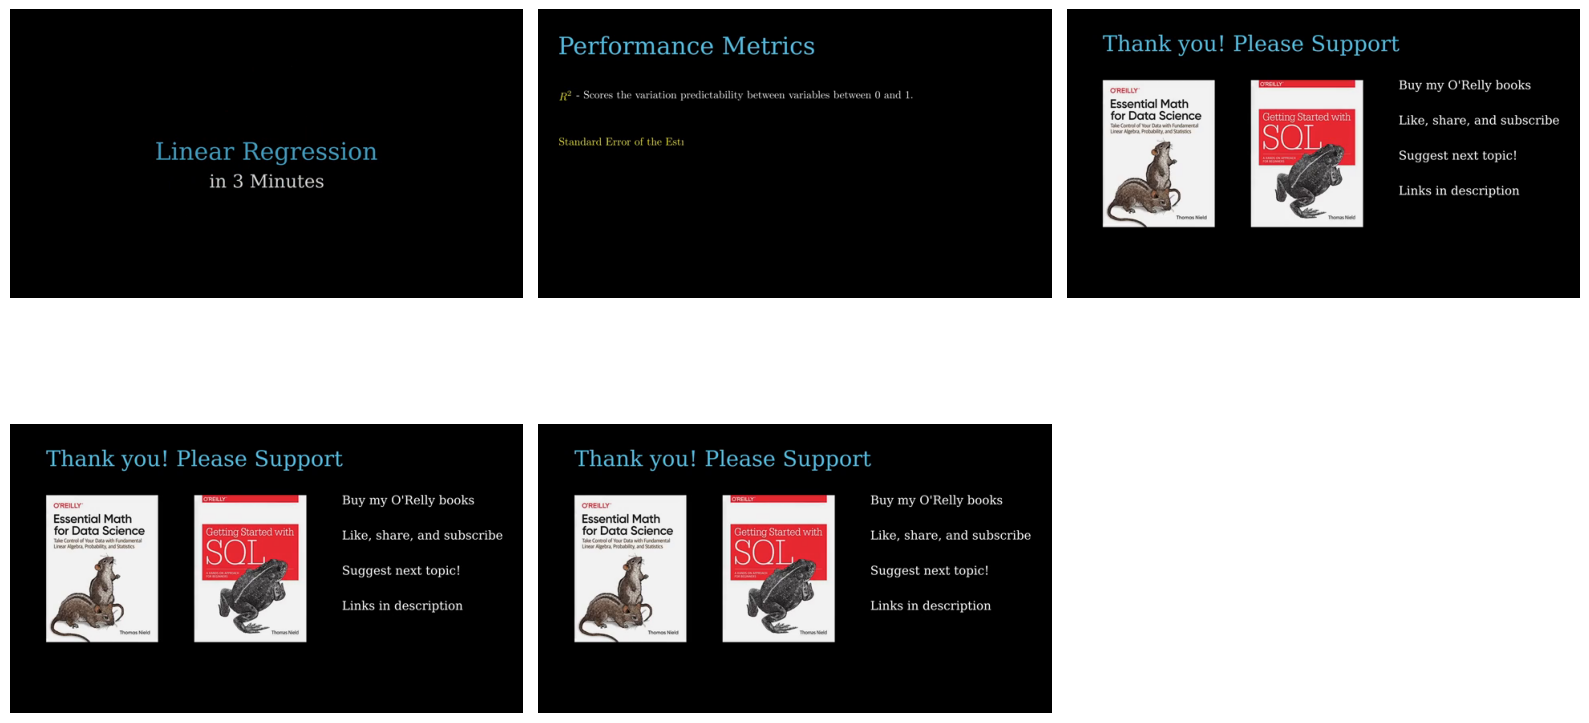

In [48]:
plot_images(images)

## Create the Multimodal Prompt Template

Define a prompt that instructs the multimodal LLM to answer the query using only the retrieved text, retrieved images, and video metadata.

In [76]:
qa_prompt = """
You are a helpful AI assistant.

Use only the provided retrieved text, images, and video metadata to answer the user's question.

Instructions:
- Use the retrieved text and images together to answer the question.
- Do not use outside knowledge or make assumptions.
- If the answer cannot be determined from the provided information, say so.
- Keep the answer clear, accurate, and concise.

---------------------
Retrieved Context:
{context_str}

---------------------
Video Metadata:
{metadata_str}

---------------------
User Question:
{query_str}

---------------------
Answer:
"""

## Convert the Video Metadata to JSON

Serialize the video metadata into JSON format so it can be included in the LLM prompt.

In [53]:
import json  # Import the JSON module to work with JSON data

# Convert the metadata dictionary into a formatted JSON string with 2-space indentation
metadata_str = json.dumps(metadata, indent=2)

In [54]:
print(type(metadata_str))

<class 'str'>


## Prepare the Context

Combine the retrieved text chunks into a single context string for the multimodal LLM.

In [56]:
# Join all text chunks into a single string, separating each chunk with two newline characters
context_str = "\n\n".join(text)

In [ ]:
from IPython.display import Markdown, display

display(Markdown(context_str))

Lenny regression is a statistical technique for modeling the relationship between an output  variable and one or more input variables.  In layman's terms, think of it as fitting a line through some data points as shown here,  so you can make predictions on unknown data, assuming there is a linear relationship between  the variables.  You might be familiar with the linear function y equals mx plus b, where y is the output  variable, also called the dependent variable.  You may also see expressed as f of x, the function of the input variable, x on the other hand  would serve as the input variable, also called the independent variable.  It's likely you'll see the coefficients m and b expressed as beta 1 and beta 0 respectively.  So what do the m and b coefficients do?  The m or beta 1 coefficient controls the slope of the line, the b or the beta 0 controls  the intercept of the line, in machine learning, we also know it as the bias.  These two coefficients are what we are solving for in linear regression.  We can also extend to multiple input variables, so x1, x2, x3, with beta 1, beta 2, and beta  3, and so on, acting as slopes for each of those variables.  In these higher dimensions, you would visualize the linear regression as a hyperplane.  So how do we fit the line to these points?  Well, you'll notice that there's these differences between the points and the line, these little  red segments, these are called residuals.  They are the differences between the data points and the predictions the line would produce.  Take each of these residuals and square them.  These are the squared errors, and notice that the large of the residuals are, the more amplified  area of the squares are.  If we total the areas of all of these squares for a given line, we will get the sum of the  squared error, and this is known as our loss function.  We need to find the beta 0 and beta 1 coefficients that will minimize that sum of squared error.  The coefficients can be solved with a variety of techniques ranging from matrix decomposition  to gradient descent, which is depicted right here.  Thankfully, a lot of libraries are available to do this for us, and we will deep dive into  these topics in other videos.  To validate a linear regression, there are a number of techniques.  Machine learning practitioners will often take a third of the data and put it into the test  data set.  The remaining two thirds will become the training data set.  The training data set will then be used to fit the regression line.  The test data set will then be used to validate the regression line.  This is done to make sure that the regression performs well on data it has not seen before.  The tricks used to evaluate the linear regression vary from the R square, standard error of the  estimate, prediction intervals, as well as statistical significance.  These are topics we will cover in future videos.  If you enjoyed this video, please like and subscribe.  Look at my two O'Reilly books, Essential Math for Data Science, and getting started with SQL.  Chapter five of Essential Math for Data Science actually covers linear regression and much  more depth.  If you want live instruction, I also do teach on the O'Reilly platform.  For a promotional link below, I teach classes including machine learning from scratch, probability,  and SQL.  Comment on what topics you would like to see next, and I will see you again on three-minute  data science.

## Load Retrieved Images

In [69]:
print(type(img))

<class 'PIL.PngImagePlugin.PngImageFile'>


In [70]:
image_paths = [
    node.metadata["file_path"]
    for node in retrieved_nodes
    if node.metadata["file_path"].endswith(".png")
]

print(image_paths)

['f:\\Multimodal-RAG-Systems\\MultiModal_RAG_with_llamaIndex_and_LanceDB\\mixed_data\\frame0003.png', 'f:\\Multimodal-RAG-Systems\\MultiModal_RAG_with_llamaIndex_and_LanceDB\\mixed_data\\frame0038.png', 'f:\\Multimodal-RAG-Systems\\MultiModal_RAG_with_llamaIndex_and_LanceDB\\mixed_data\\frame0040.png', 'f:\\Multimodal-RAG-Systems\\MultiModal_RAG_with_llamaIndex_and_LanceDB\\mixed_data\\frame0042.png', 'f:\\Multimodal-RAG-Systems\\MultiModal_RAG_with_llamaIndex_and_LanceDB\\mixed_data\\frame0041.png']


In [71]:
from llama_index.core import SimpleDirectoryReader

image_documents = SimpleDirectoryReader(
    input_files=image_paths
).load_data()

## Initialize the Gemini Multimodal LLM

In [72]:
import os
from dotenv import load_dotenv

load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [73]:
from llama_index.multi_modal_llms.gemini import GeminiMultiModal

gemini_mm_llm = GeminiMultiModal(
    model_name="models/gemini-2.5-flash",
    api_key=GOOGLE_API_KEY,
)

2026-07-13 15:23:33,495 - WARNING - C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11512\3887196050.py:3: DeprecationWarning: Call to deprecated class GeminiMultiModal. (This package has been deprecated and will no longer be maintained. Please use llama-index-llms-google-genai instead. See Multi Modal LLMs documentation for a complete guide on migration: https://docs.llamaindex.ai/en/stable/understanding/using_llms/using_llms/#multi-modal-llms.) -- Deprecated since version 0.5.1.
  gemini_mm_llm = GeminiMultiModal(



## Define the User Query

In [75]:
query_str = (
    "Can you explain what Linear Regression is and "
    "what the equation of Linear Regression is?"
)

## Generate the Response Using Gemini

In [77]:
response = gemini_mm_llm.complete(
    prompt=qa_prompt.format(
        context_str=context_str,
        metadata_str=metadata_str,
        query_str=query_str,
    ),
    image_documents=image_documents,
)

print(response.text)

ValidationError: 5 validation errors for ChatMessage
blocks.1
  Unable to extract tag using discriminator 'block_type' [type=union_tag_not_found, input_value=ImageDocument(id_='e88e3f...data_str}\n\n{content}'), input_type=ImageDocument]
    For further information visit https://errors.pydantic.dev/2.13/v/union_tag_not_found
blocks.2
  Unable to extract tag using discriminator 'block_type' [type=union_tag_not_found, input_value=ImageDocument(id_='e07d2b...data_str}\n\n{content}'), input_type=ImageDocument]
    For further information visit https://errors.pydantic.dev/2.13/v/union_tag_not_found
blocks.3
  Unable to extract tag using discriminator 'block_type' [type=union_tag_not_found, input_value=ImageDocument(id_='ec75e2...data_str}\n\n{content}'), input_type=ImageDocument]
    For further information visit https://errors.pydantic.dev/2.13/v/union_tag_not_found
blocks.4
  Unable to extract tag using discriminator 'block_type' [type=union_tag_not_found, input_value=ImageDocument(id_='a

# Perform Multimodal Inference with Gemini

The current `GeminiMultiModal` wrapper in LlamaIndex has compatibility issues with the latest `ImageDocument` objects.

Instead of using the LlamaIndex wrapper, we'll use the **official Google GenAI SDK** for multimodal inference.

This approach provides several advantages:

- Officially supported by Google
- Better compatibility with the latest Gemini models
- Works reliably with multiple images
- Easier to maintain in future versions

The retrieval pipeline (LanceDB + LlamaIndex) remains exactly the same. We only replace the final inference step.

## Import Required Libraries

In [83]:
from google import genai
from google.genai import types
from PIL import Image

## Initialize the Gemini Client

Create a Gemini client using your API key.

In [84]:
import os
from dotenv import load_dotenv

load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

client = genai.Client(api_key=GOOGLE_API_KEY)

## Create the Prompt

Combine the retrieved text, metadata, and user query into a single prompt.

In [85]:
qa_prompt = f"""
You are a helpful AI assistant.

Use ONLY the retrieved context, retrieved images and video metadata to answer the user's question.

Instructions:
- Use both the retrieved text and retrieved images.
- Do not use external knowledge.
- If the answer is not present in the provided information, clearly state that.
- Keep the answer concise and accurate.

-----------------------
Retrieved Context

{context_str}

-----------------------
Video Metadata

{metadata_str}

-----------------------
Question

{query_str}

-----------------------
Answer:
"""

## Prepare the Retrieved Images for Gemini

After retrieving the most relevant nodes from the Multimodal Vector Index, we need to prepare the input for the Gemini model.

The retriever can return both **text** and **image** nodes. Our text context has already been combined into the prompt (`qa_prompt`), so in this step we focus on the retrieved images.

We will:

1. Create a list that will be sent to Gemini.
2. Add the text prompt as the first item.
3. Iterate through the retrieved nodes.
4. Identify image files using their file extensions.
5. Load each image into memory using the Pillow (`PIL`) library.
6. Append the images to the input list.

The final input sent to Gemini will have the following structure:

```text
[
    Prompt,
    Image 1,
    Image 2,
    Image 3,
    ...
]
```

Gemini can process both text and images together, allowing it to answer questions using the retrieved context and the relevant video frames.

In [ ]:
from PIL import Image

# Create a list that will be sent to Gemini.
# The first element is the text prompt containing the retrieved context,
# metadata, and the user's question.
contents = [qa_prompt]

# Iterate through all retrieved nodes returned by the retriever.
for node in retrieved_nodes:

    # Get the original file path stored in the node's metadata.
    file_path = node.metadata.get("file_path")

    # Check whether the retrieved file is an image.
    # This filters out text files and keeps only image frames.
    if file_path.lower().endswith((".png", ".jpg", ".jpeg")):

        # Open the image using Pillow and add it to the input list.
        # Gemini will analyze these images together with the text prompt.
        contents.append(Image.open(file_path))

```text
contents
│
├── Text Prompt
│     ├── Instructions
│     ├── Retrieved Context (Actual Transcript)
│     ├── Video Metadata
│     └── User Question
│
├── Retrieved Image 1
├── Retrieved Image 2
├── Retrieved Image 3
└── ...
```

## Generate the Final Answer

Send the prompt together with all retrieved images to Gemini 2.5 Flash.

In [96]:
response = client.models.generate_content(
    model="gemini-flash-latest",
    contents=contents,
)

2026-07-13 15:52:29,217 - INFO - AFC is enabled with max remote calls: 10.
2026-07-13 15:52:43,251 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-flash-latest:generateContent "HTTP/1.1 200 OK"


## Display the Response

In [97]:
print(response.text)

Based on the provided context, **Linear Regression** (referred to in the transcript as "Lenny regression") is a statistical technique used to model the relationship between an output variable and one or more input variables. It works by fitting a line (or a hyperplane in higher dimensions) through data points to predict unknown data, assuming a linear relationship exists between the variables.

### The Equation of Linear Regression:
The relationship is expressed using the linear function:

$$y = mx + b$$

Or alternatively:
$$f(x) = \beta_1 x + \beta_0$$

Where:
* **$y$** (or **$f(x)$**) is the output variable (dependent variable).
* **$x$** is the input variable (independent variable).
* **$m$** (or **$\beta_1$**) is the coefficient that controls the slope of the line.
* **$b$** (or **$\beta_0$**) is the coefficient that controls the intercept of the line (also known as the **bias** in machine learning).

For multiple input variables ($x_1, x_2, x_3, \dots$), the equation extends to in

## Why not use `GeminiMultiModal` from LlamaIndex?

The notebook originally used:

- OpenAI GPT-4 Vision
- `OpenAIMultiModal`

We attempted to replace it with:

- `GeminiMultiModal`

However, with the current package versions:

- llama-index 0.14.x
- llama-index-core 0.14.x
- llama-index-multi-modal-llms-gemini 0.6.x

the wrapper raises a `ValidationError` while processing `ImageDocument` objects.

This is a compatibility issue inside the library rather than an issue with the notebook.

Using the official Google GenAI SDK avoids this problem while keeping the rest of the Multimodal RAG pipeline unchanged.

The final architecture becomes:

Video
→ Extract Frames & Audio
→ Convert Audio to Text
→ Create Text + Image Embeddings
→ Store Embeddings in LanceDB
→ Retrieve Relevant Text & Images
→ Gemini 2.5 Flash (Official SDK)
→ Final Answer

                 Video
                   │
        ┌──────────┴──────────┐
        │                     │
     Extract Frames      Extract Audio
        │                     │
        │              Speech-to-Text
        └──────────┬──────────┘
                   │
        Text + Image Documents
                   │
             CLIP + BGE Embeddings
                   │
                 LanceDB
                   │
     MultiModalVectorStoreIndex
                   │
               Retriever
                   │
      Retrieved Text + Images
                   │
      Google Gemini 2.5 Flash
                   │
             Final Response

## Query Execution Flow

Once the **Multimodal Vector Index** has been created, the following workflow is executed whenever a user asks a question.

The retriever first searches the vector database to find the most relevant **text** and **image** embeddings. The retrieved information is then combined with the video metadata and the user's question to build a prompt. Finally, the prompt and the retrieved images are sent to **Gemini Flash**, which performs multimodal reasoning to generate a grounded response.

```text
                           User Query
                                │
                                ▼
         query = "What is Linear Regression?"
                                │
                                ▼
                    Multimodal Retriever
                                │
          Searches both text and image embeddings
                  stored in LanceDB
                                │
              ┌─────────────────┴─────────────────┐
              │                                   │
              ▼                                   ▼
     Retrieved Text                      Retrieved Images
     (context_str)                  (frame0003.png, ...)
              │                                   │
              └─────────────────┬─────────────────┘
                                │
                                ▼
                    Prepare Video Metadata
                        (metadata_str)
                                │
                                ▼
                    Build Prompt (qa_prompt)
                                │
        Prompt contains:
        • Instructions
        • Retrieved Text Context
        • Video Metadata
        • User Question
                                │
                                ▼
             Create Multimodal Input (contents)
                                │
        contents = [
            qa_prompt,
            image1,
            image2,
            image3,
            ...
        ]
                                │
                                ▼
             Send Request to Gemini Flash
           (Text Prompt + Retrieved Images)
                                │
                                ▼
            Gemini performs multimodal reasoning
                    using:
                    • Retrieved Text
                    • Retrieved Images
                    • Video Metadata
                    • User Question
                                │
                                ▼
               Generate Grounded Answer
                                │
                                ▼
                  Display Final Response
```

### Summary

1. The user submits a query.
2. The retriever searches **LanceDB** using both text and image embeddings.
3. Relevant text chunks and image frames are retrieved.
4. The retrieved text, video metadata, and user query are combined into a text prompt.
5. The retrieved images are loaded and appended to the multimodal input.
6. The prompt and images are sent together to **Gemini Flash**.
7. Gemini jointly reasons over both modalities and generates a grounded response based only on the retrieved information.